In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df_users = pd.read_csv("acc-data/ACC-usagers-2018.csv")
df_users

,Num_Acc,place,catu,grav,sexe,trajet,secu,locp,actp,etatp,an_nais,num_veh
0,201800000001,1.0,1,3,1,0.0,11.0,0.0,0.0,0.0,1928.0,B01
1,201800000001,1.0,1,1,1,5.0,11.0,0.0,0.0,0.0,1960.0,A01
2,201800000002,1.0,1,1,1,0.0,11.0,0.0,0.0,0.0,1947.0,A01
3,201800000002,NaN,3,4,1,0.0,2.0,2.0,3.0,1.0,1959.0,A01
4,201800000003,1.0,1,3,1,5.0,21.0,0.0,0.0,0.0,1987.0,A01
...,...,...,...,...,...,...,...,...,...,...,...,...
130164,201800057781,NaN,3,4,1,9.0,3.0,4.0,3.0,1.0,1975.0,A01
130165,201800057782,1.0,1,4,2,9.0,11.0,NaN,NaN,NaN,1993.0,A01
130166,201800057782,1.0,1,4,1,9.0,21.0,NaN,NaN,NaN,1974.0,B01
130167,201800057783,1.0,1,4,1,9.0,11.0,NaN,NaN,NaN,1973.0,B01


In [11]:
df1 = df_users[["Num_Acc","grav","an_nais","catu"]]
df1 = df1.where(df1['catu'] == 1 )
df1 = df1.dropna()
df1.reset_index()
df1

,Num_Acc,grav,an_nais,catu
0,2.018000e+11,3.0,1928.0,1.0
1,2.018000e+11,1.0,1960.0,1.0
2,2.018000e+11,1.0,1947.0,1.0
4,2.018000e+11,3.0,1987.0,1.0
5,2.018000e+11,1.0,1977.0,1.0
...,...,...,...,...
130163,2.018001e+11,1.0,1989.0,1.0
130165,2.018001e+11,4.0,1993.0,1.0
130166,2.018001e+11,4.0,1974.0,1.0
130167,2.018001e+11,4.0,1973.0,1.0


In [36]:
results = df1.groupby("an_nais")["Num_Acc"].size()
results = results.reset_index()
results

,an_nais,Num_Acc
0,1917.0,1
1,1918.0,2
2,1919.0,1
3,1920.0,1
4,1921.0,4
...,...,...
94,2011.0,16
95,2012.0,10
96,2013.0,2
97,2014.0,9


In [91]:
"""n = len(results)

in_per = lambda x : x/n
results['Num_Acc'] = results['Num_Acc'].map(in_per)

results"""

"n = len(results)\n\nin_per = lambda x : x/n\nresults['Num_Acc'] = results['Num_Acc'].map(in_per)\n\nresults"

In [98]:
df1
results2 = df1.groupby(["grav",'an_nais'])["Num_Acc"].size()
results2 = results2.reset_index()
results2

,grav,an_nais,Num_Acc
0,1.0,1918.0,1
1,1.0,1919.0,1
2,1.0,1920.0,1
3,1.0,1921.0,2
4,1.0,1922.0,3
...,...,...,...
360,4.0,2010.0,10
361,4.0,2011.0,9
362,4.0,2012.0,6
363,4.0,2014.0,6


([<matplotlib.axis.XTick at 0x132371fd0>,
 [Text(1917.0, 0, '1917'),
  Text(1927.0, 0, '1927'),
  Text(1937.0, 0, '1937'),
  Text(1946.0, 0, '1946'),
  Text(1956.0, 0, '1956'),
  Text(1966.0, 0, '1966'),
  Text(1976.0, 0, '1976'),
  Text(1986.0, 0, '1986'),
  Text(1995.0, 0, '1995'),
  Text(2005.0, 0, '2005'),
  Text(2015.0, 0, '2015')])

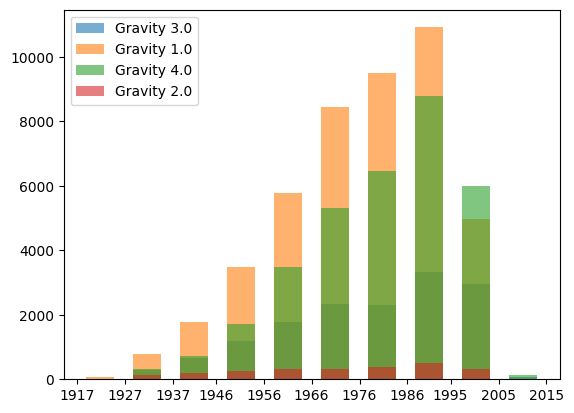

In [111]:
for grav_level in df1['grav'].unique():
    subset = df1[df1['grav'] == grav_level]['an_nais']
    plt.hist(subset, bins=bins, alpha=0.6, label=f'Gravity {grav_level}',rwidth=0.6)

plt.legend()
plt.xticks(bins.round())



(array([  112.,  1503.,  3361.,  6639., 11336., 16411., 18650., 23532.,
       14211.,   243.]), array([1917. , 1926.8, 1936.6, 1946.4, 1956.2, 1966. , 1975.8, 1985.6,
       1995.4, 2005.2, 2015. ]), <BarContainer object of 10 artists>)


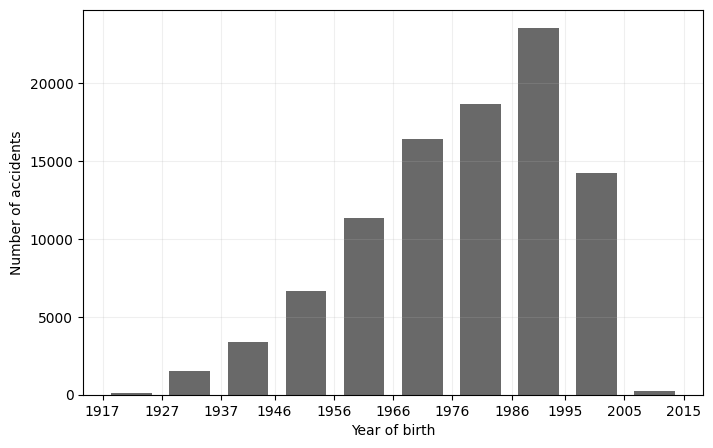

In [ ]:
bins = np.linspace(1917,2015,11)

#plt.bar(x=results.an_nais,height=results.Num_Acc)
fig , ax = plt.subplots(figsize=(8,5))
counts = ax.hist(results["an_nais"], bins=bins, weights=results["Num_Acc"],color='dimgray',rwidth=0.7)
ax.grid(True,alpha=0.2)
ax.set_xticks(bins.round())
ax.set_xlabel("Year of birth")
ax.set_ylabel("Number of accidents")
print()
print(counts)



Text(0.5, 0, 'Year of birth')

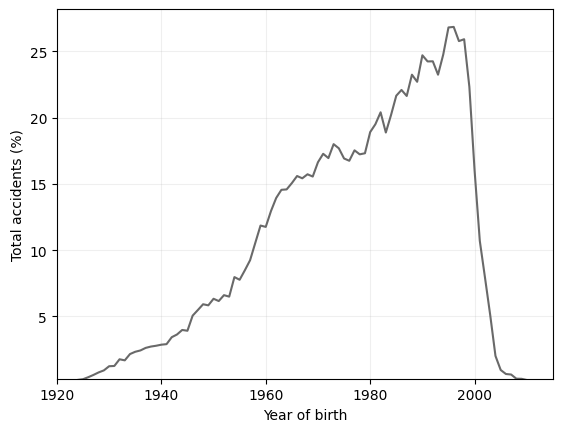

In [15]:
fig , ax = plt.subplots()
ax.plot(results["an_nais"],results["Num_Acc"],'dimgray')
ax.grid(True,alpha=0.2)
ax.set_ylim(ymin=0.3)
ax.set_xlim(xmin=1920,xmax=2015)
ax.set_ylabel("Total accidents (%)")
ax.set_xlabel("Year of birth")
